In [1]:
import os
import json

import numpy as np
import pandas as pd

ROOT = r'E:\KNEE_fewshot\revision'
RUNS_DIR = os.path.join(ROOT, 'runs')
FIG_DIR = os.path.join(ROOT, 'figures')
TAB_DIR = os.path.join(ROOT, 'tables')
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)

MODELS = ['vanilla', 'baseline', 'ordinal', 'attention', 'full']
BACKBONES = ['resnet18', 'densenet121']
SEEDS = [0, 1, 2]
REQUIRED_FILES = ['best_model.pth', 'config.json', 'history.json', 'outputs.npz', 'results.json']
SHARED_KEYS = ['img_size', 'epochs', 'lr', 'lr_factor', 'lr_patience', 'n_support', 'n_query',
               'episodes_per_epoch', 'batch_size', 'ordinal_alpha', 'ordinal_margin', 'cbam_reduction']

expected = [f"{m}_{b}_seed{s}" for m in MODELS for b in BACKBONES for s in SEEDS]
found = sorted(d for d in os.listdir(RUNS_DIR) if os.path.isdir(os.path.join(RUNS_DIR, d)))
missing = sorted(set(expected) - set(found))
extra = sorted(set(found) - set(expected))
print(f"Run folders: {len(found)} found, {len(expected)} expected")
if missing:
    raise FileNotFoundError(f"Missing runs: {missing}")
if extra:
    print(f"Unexpected folders (ignored): {extra}")

rows, problems = [], []
ref_shared = ref_labels = ref_files = None

for run in expected:
    run_dir = os.path.join(RUNS_DIR, run)
    absent = [f for f in REQUIRED_FILES if not os.path.exists(os.path.join(run_dir, f))]
    if absent:
        problems.append(f"{run}: missing {absent}")
        continue

    with open(os.path.join(run_dir, 'results.json')) as f:
        res = json.load(f)
    cfg = res['config']
    model, backbone, seed_tag = run.split('_')
    seed = int(seed_tag.replace('seed', ''))

    if (cfg['model'], cfg['backbone'], cfg['seed']) != (model, backbone, seed):
        problems.append(f"{run}: config does not match folder name")

    shared = {k: cfg[k] for k in SHARED_KEYS}
    if ref_shared is None:
        ref_shared = shared
    elif shared != ref_shared:
        problems.append(f"{run}: hyperparameters differ from the other runs")

    out = np.load(os.path.join(run_dir, 'outputs.npz'))
    if ref_labels is None:
        ref_labels, ref_files = out['test_labels'], out['test_files']
    elif not (np.array_equal(out['test_labels'], ref_labels)
              and np.array_equal(out['test_files'], ref_files)):
        problems.append(f"{run}: test images or labels differ from the other runs")

    rows.append(dict(model=model, backbone=backbone, seed=seed,
                     best_epoch=res['best_epoch'], train_minutes=res['train_minutes'],
                     torch=cfg['versions']['torch'], gpu=cfg['versions']['gpu'],
                     **res['test']))

df = pd.DataFrame(rows)
df['model'] = pd.Categorical(df['model'], MODELS, ordered=True)
df['backbone'] = pd.Categorical(df['backbone'], BACKBONES, ordered=True)
df = df.sort_values(['backbone', 'model', 'seed']).reset_index(drop=True)
df.to_csv(os.path.join(TAB_DIR, 'all_runs_test_metrics.csv'), index=False)

print(f"Runs loaded: {len(df)}")
print(f"Test set: {len(ref_labels)} images, per KL grade {np.bincount(ref_labels).tolist()}")
print(f"Shared hyperparameters: {ref_shared}")
print(f"GPU: {sorted(df['gpu'].unique())} | torch: {sorted(df['torch'].unique())}")
print(f"Total training time: {df['train_minutes'].sum() / 60:.1f} GPU hours")
print("Problems:", problems if problems else "none")

cols = ['backbone', 'model', 'seed', 'best_epoch', 'accuracy', 'f1_macro', 'f1_kl1', 'f1_kl4', 'mae', 'qwk']
print()
print(df[cols].round(4).to_string(index=False))

Run folders: 30 found, 30 expected
Runs loaded: 30
Test set: 1656 images, per KL grade [639, 296, 447, 223, 51]
Shared hyperparameters: {'img_size': 224, 'epochs': 30, 'lr': 0.0001, 'lr_factor': 0.5, 'lr_patience': 5, 'n_support': 5, 'n_query': 5, 'episodes_per_epoch': 115, 'batch_size': 32, 'ordinal_alpha': 0.5, 'ordinal_margin': 0.5, 'cbam_reduction': 16}
GPU: ['Tesla T4'] | torch: ['2.11.0+cu128']
Total training time: 15.5 GPU hours
Problems: none

   backbone     model  seed  best_epoch  accuracy  f1_macro  f1_kl1  f1_kl4    mae    qwk
   resnet18   vanilla     0          20    0.6564    0.6468  0.2362  0.8043 0.4130 0.8065
   resnet18   vanilla     1          17    0.6413    0.6718  0.3084  0.8485 0.4106 0.8159
   resnet18   vanilla     2          12    0.6461    0.6723  0.3323  0.8367 0.3986 0.8207
   resnet18  baseline     0          21    0.6431    0.6725  0.3288  0.8515 0.4040 0.8207
   resnet18  baseline     1          24    0.6522    0.6857  0.3813  0.8367 0.3786 0.8372
   r

In [2]:
METRICS = ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro', 'mae', 'qwk', 'within_one',
           'f1_kl0', 'f1_kl1', 'f1_kl2', 'f1_kl3', 'f1_kl4']
MODEL_LABELS = {
    'vanilla': 'Softmax CNN',
    'baseline': 'ProtoNet',
    'ordinal': 'ProtoNet + Ordinal',
    'attention': 'ProtoNet + CBAM',
    'full': 'ProtoNet + Ordinal + CBAM',
}
BACKBONE_LABELS = {'resnet18': 'ResNet-18', 'densenet121': 'DenseNet-121'}

agg = df.groupby(['backbone', 'model'], observed=True)[METRICS].agg(['mean', 'std'])

numeric = agg.copy()
numeric.columns = [f"{m}_{s}" for m, s in numeric.columns]
numeric.to_csv(os.path.join(TAB_DIR, 'summary_mean_std.csv'))

formatted = pd.DataFrame(index=agg.index)
for m in METRICS:
    formatted[m] = [f"{mu:.3f} ± {sd:.3f}" for mu, sd in zip(agg[(m, 'mean')], agg[(m, 'std')])]
formatted = formatted.reset_index()
formatted.insert(0, 'Backbone', formatted.pop('backbone').map(BACKBONE_LABELS))
formatted.insert(1, 'Model', formatted.pop('model').map(MODEL_LABELS))
formatted.to_csv(os.path.join(TAB_DIR, 'table_main_results.csv'), index=False)

overall_cols = ['Backbone', 'Model', 'accuracy', 'f1_macro', 'precision_macro',
                'recall_macro', 'mae', 'qwk', 'within_one']
per_class_cols = ['Backbone', 'Model', 'f1_kl0', 'f1_kl1', 'f1_kl2', 'f1_kl3', 'f1_kl4']

pd.set_option('display.width', 250)
print("Overall test performance (mean ± SD, 3 seeds)")
print(formatted[overall_cols].to_string(index=False))
print("\nPer-grade test F1 (mean ± SD, 3 seeds)")
print(formatted[per_class_cols].to_string(index=False))

Overall test performance (mean ± SD, 3 seeds)
    Backbone                     Model      accuracy      f1_macro precision_macro  recall_macro           mae           qwk    within_one
   ResNet-18               Softmax CNN 0.648 ± 0.008 0.664 ± 0.015   0.681 ± 0.011 0.652 ± 0.016 0.407 ± 0.008 0.814 ± 0.007 0.945 ± 0.013
   ResNet-18                  ProtoNet 0.649 ± 0.005 0.681 ± 0.007   0.688 ± 0.013 0.679 ± 0.005 0.389 ± 0.013 0.830 ± 0.008 0.961 ± 0.008
   ResNet-18        ProtoNet + Ordinal 0.656 ± 0.010 0.686 ± 0.006   0.693 ± 0.005 0.686 ± 0.007 0.375 ± 0.013 0.841 ± 0.007 0.969 ± 0.003
   ResNet-18           ProtoNet + CBAM 0.647 ± 0.009 0.680 ± 0.003   0.692 ± 0.004 0.675 ± 0.004 0.390 ± 0.010 0.830 ± 0.005 0.963 ± 0.001
   ResNet-18 ProtoNet + Ordinal + CBAM 0.651 ± 0.004 0.675 ± 0.000   0.677 ± 0.008 0.678 ± 0.007 0.386 ± 0.004 0.833 ± 0.004 0.963 ± 0.002
DenseNet-121               Softmax CNN 0.690 ± 0.012 0.687 ± 0.012   0.700 ± 0.010 0.679 ± 0.018 0.361 ± 0.012 0.838 ± 0

In [3]:
from scipy.stats import binomtest

N_BOOT = 2000
K = 5
STAT_METRICS = ['accuracy', 'f1_macro', 'f1_kl1', 'qwk']
QWK_WEIGHTS = np.subtract.outer(np.arange(K), np.arange(K)) ** 2 / (K - 1) ** 2


def confusion(y_true, y_pred):
    return np.bincount(K * y_true + y_pred, minlength=K * K).reshape(K, K)


def metrics_from_cm(cm):
    n = cm.sum()
    tp = np.diag(cm)
    col, row = cm.sum(axis=0), cm.sum(axis=1)
    prec = np.divide(tp, col, out=np.zeros(K), where=col > 0)
    rec = np.divide(tp, row, out=np.zeros(K), where=row > 0)
    f1 = np.divide(2 * prec * rec, prec + rec, out=np.zeros(K), where=(prec + rec) > 0)
    qwk = 1 - (QWK_WEIGHTS * cm).sum() / (QWK_WEIGHTS * np.outer(row, col) / n).sum()
    return np.array([tp.sum() / n, f1.mean(), f1[1], qwk])


y_test = ref_labels
preds = {run: np.load(os.path.join(RUNS_DIR, run, 'outputs.npz'))['test_preds'] for run in expected}
run_index = {run: j for j, run in enumerate(expected)}
point = np.array([metrics_from_cm(confusion(y_test, preds[run])) for run in expected])

# Sanity check against the metrics saved during training
df['run'] = df['model'].astype(str) + '_' + df['backbone'].astype(str) + '_seed' + df['seed'].astype(str)
saved = df.set_index('run').loc[expected, STAT_METRICS].to_numpy()
print(f"Max difference from saved metrics: {np.abs(point - saved).max():.2e}")

# Paired bootstrap: the same resampled test images are used for every run
rng = np.random.default_rng(0)
n_test = len(y_test)
boot = np.empty((N_BOOT, len(expected), len(STAT_METRICS)))
for b in range(N_BOOT):
    idx = rng.integers(0, n_test, n_test)
    yb = y_test[idx]
    for run, j in run_index.items():
        boot[b, j] = metrics_from_cm(confusion(yb, preds[run][idx]))


def seed_mean(values, model, backbone):
    cols = [run_index[f"{model}_{backbone}_seed{s}"] for s in SEEDS]
    return values[..., cols, :].mean(axis=-2)


def holm(pvals):
    order = np.argsort(pvals)
    adjusted = np.empty(len(pvals))
    running = 0.0
    for rank, i in enumerate(order):
        running = max(running, (len(pvals) - rank) * pvals[i])
        adjusted[i] = min(1.0, running)
    return adjusted


COMPARISONS = ([(m, 'vanilla') for m in ['baseline', 'ordinal', 'attention', 'full']] +
               [(m, 'baseline') for m in ['ordinal', 'attention', 'full']])

records = []
for backbone in BACKBONES:
    for a, b in COMPARISONS:
        obs = seed_mean(point, a, backbone) - seed_mean(point, b, backbone)
        dist = seed_mean(boot, a, backbone) - seed_mean(boot, b, backbone)
        lo, hi = np.percentile(dist, [2.5, 97.5], axis=0)
        p = np.minimum(1.0, 2 * np.minimum((dist <= 0).mean(axis=0), (dist >= 0).mean(axis=0)))

        # Exact McNemar test on accuracy, one test per seed
        mcnemar = []
        for s in SEEDS:
            ca = preds[f"{a}_{backbone}_seed{s}"] == y_test
            cb = preds[f"{b}_{backbone}_seed{s}"] == y_test
            n01, n10 = int((ca & ~cb).sum()), int((~ca & cb).sum())
            mcnemar.append(binomtest(min(n01, n10), n01 + n10, 0.5).pvalue if n01 + n10 else 1.0)

        for k, metric in enumerate(STAT_METRICS):
            records.append(dict(backbone=BACKBONE_LABELS[backbone],
                                comparison=f"{MODEL_LABELS[a]} vs {MODEL_LABELS[b]}",
                                metric=metric, diff=obs[k], ci_low=lo[k], ci_high=hi[k], p=p[k],
                                mcnemar_p=('; '.join(f"{v:.3f}" for v in mcnemar)
                                           if metric == 'accuracy' else '')))

stats = pd.DataFrame(records)
stats['p_holm'] = np.nan
for (bb, metric), grp in stats.groupby(['backbone', 'metric']):
    stats.loc[grp.index, 'p_holm'] = holm(grp['p'].to_numpy())
stats.to_csv(os.path.join(TAB_DIR, 'statistical_comparisons.csv'), index=False)


def fmt_p(p):
    return '<0.001' if p < 0.001 else f"{p:.3f}"


for metric in STAT_METRICS:
    sub = stats[stats['metric'] == metric]
    print(f"\n{metric}: difference (A - B), 95% bootstrap CI, p, Holm-adjusted p"
          + (", McNemar p per seed" if metric == 'accuracy' else ""))
    for _, r in sub.iterrows():
        line = (f"  {r['backbone']:12s} {r['comparison']:48s} {r['diff']:+.3f} "
                f"[{r['ci_low']:+.3f}, {r['ci_high']:+.3f}]  p={fmt_p(r['p'])}  p_holm={fmt_p(r['p_holm'])}")
        if metric == 'accuracy':
            line += f"  McNemar: {r['mcnemar_p']}"
        print(line)

Max difference from saved metrics: 1.11e-16

accuracy: difference (A - B), 95% bootstrap CI, p, Holm-adjusted p, McNemar p per seed
  ResNet-18    ProtoNet vs Softmax CNN                          +0.001 [-0.014, +0.016]  p=0.890  p_holm=1.000  McNemar: 0.288; 0.402; 0.603
  ResNet-18    ProtoNet + Ordinal vs Softmax CNN                +0.008 [-0.007, +0.024]  p=0.342  p_holm=1.000  McNemar: 0.377; 0.055; 0.402
  ResNet-18    ProtoNet + CBAM vs Softmax CNN                   -0.001 [-0.015, +0.014]  p=0.939  p_holm=1.000  McNemar: 0.602; 0.271; 0.471
  ResNet-18    ProtoNet + Ordinal + CBAM vs Softmax CNN         +0.003 [-0.012, +0.019]  p=0.698  p_holm=1.000  McNemar: 0.503; 0.507; 0.451
  ResNet-18    ProtoNet + Ordinal vs ProtoNet                   +0.006 [-0.005, +0.019]  p=0.268  p_holm=1.000  McNemar: 0.910; 0.198; 0.715
  ResNet-18    ProtoNet + CBAM vs ProtoNet                      -0.002 [-0.014, +0.010]  p=0.740  p_holm=1.000  McNemar: 0.572; 0.815; 0.115
  ResNet-18    ProtoNe

In [4]:
from sklearn.metrics import roc_auc_score, average_precision_score

y_onehot = np.eye(K)[y_test]
auc_rows = []
for run in expected:
    probs = np.load(os.path.join(RUNS_DIR, run, 'outputs.npz'))['test_probs']
    model, backbone, seed_tag = run.split('_')
    row = dict(model=model, backbone=backbone, seed=int(seed_tag.replace('seed', '')))
    for k in range(K):
        row[f'roc_kl{k}'] = roc_auc_score(y_onehot[:, k], probs[:, k])
        row[f'pr_kl{k}'] = average_precision_score(y_onehot[:, k], probs[:, k])
    row['roc_macro'] = np.mean([row[f'roc_kl{k}'] for k in range(K)])
    row['pr_macro'] = np.mean([row[f'pr_kl{k}'] for k in range(K)])
    auc_rows.append(row)

auc_df = pd.DataFrame(auc_rows)
auc_df['model'] = pd.Categorical(auc_df['model'], MODELS, ordered=True)
auc_df['backbone'] = pd.Categorical(auc_df['backbone'], BACKBONES, ordered=True)
auc_df.to_csv(os.path.join(TAB_DIR, 'all_runs_auc.csv'), index=False)

AUC_COLS = ['roc_macro', 'pr_macro', 'roc_kl1', 'pr_kl1', 'roc_kl4', 'pr_kl4']
auc_agg = auc_df.groupby(['backbone', 'model'], observed=True)[AUC_COLS].agg(['mean', 'std'])

auc_table = pd.DataFrame(index=auc_agg.index)
for c in AUC_COLS:
    auc_table[c] = [f"{mu:.3f} ± {sd:.3f}" for mu, sd in zip(auc_agg[(c, 'mean')], auc_agg[(c, 'std')])]
auc_table = auc_table.reset_index()
auc_table.insert(0, 'Backbone', auc_table.pop('backbone').map(BACKBONE_LABELS))
auc_table.insert(1, 'Model', auc_table.pop('model').map(MODEL_LABELS))
auc_table.to_csv(os.path.join(TAB_DIR, 'table_auc.csv'), index=False)

prevalence = np.bincount(y_test) / len(y_test)
print("One-vs-rest ROC-AUC and PR-AUC on the test set (mean ± SD, 3 seeds)")
print(f"PR-AUC of a random classifier equals class prevalence: "
      f"KL1 = {prevalence[1]:.3f}, KL4 = {prevalence[4]:.3f}\n")
print(auc_table.to_string(index=False))

One-vs-rest ROC-AUC and PR-AUC on the test set (mean ± SD, 3 seeds)
PR-AUC of a random classifier equals class prevalence: KL1 = 0.179, KL4 = 0.031

    Backbone                     Model     roc_macro      pr_macro       roc_kl1        pr_kl1       roc_kl4        pr_kl4
   ResNet-18               Softmax CNN 0.877 ± 0.009 0.706 ± 0.014 0.683 ± 0.023 0.282 ± 0.015 0.985 ± 0.006 0.894 ± 0.018
   ResNet-18                  ProtoNet 0.892 ± 0.005 0.731 ± 0.007 0.717 ± 0.013 0.303 ± 0.015 0.997 ± 0.000 0.933 ± 0.007
   ResNet-18        ProtoNet + Ordinal 0.896 ± 0.003 0.735 ± 0.006 0.722 ± 0.006 0.303 ± 0.014 0.996 ± 0.001 0.925 ± 0.006
   ResNet-18           ProtoNet + CBAM 0.892 ± 0.004 0.730 ± 0.006 0.718 ± 0.017 0.303 ± 0.023 0.996 ± 0.002 0.925 ± 0.028
   ResNet-18 ProtoNet + Ordinal + CBAM 0.892 ± 0.002 0.730 ± 0.006 0.714 ± 0.007 0.304 ± 0.006 0.997 ± 0.000 0.918 ± 0.017
DenseNet-121               Softmax CNN 0.904 ± 0.005 0.749 ± 0.008 0.740 ± 0.017 0.333 ± 0.016 0.996 ± 0.001 0.92

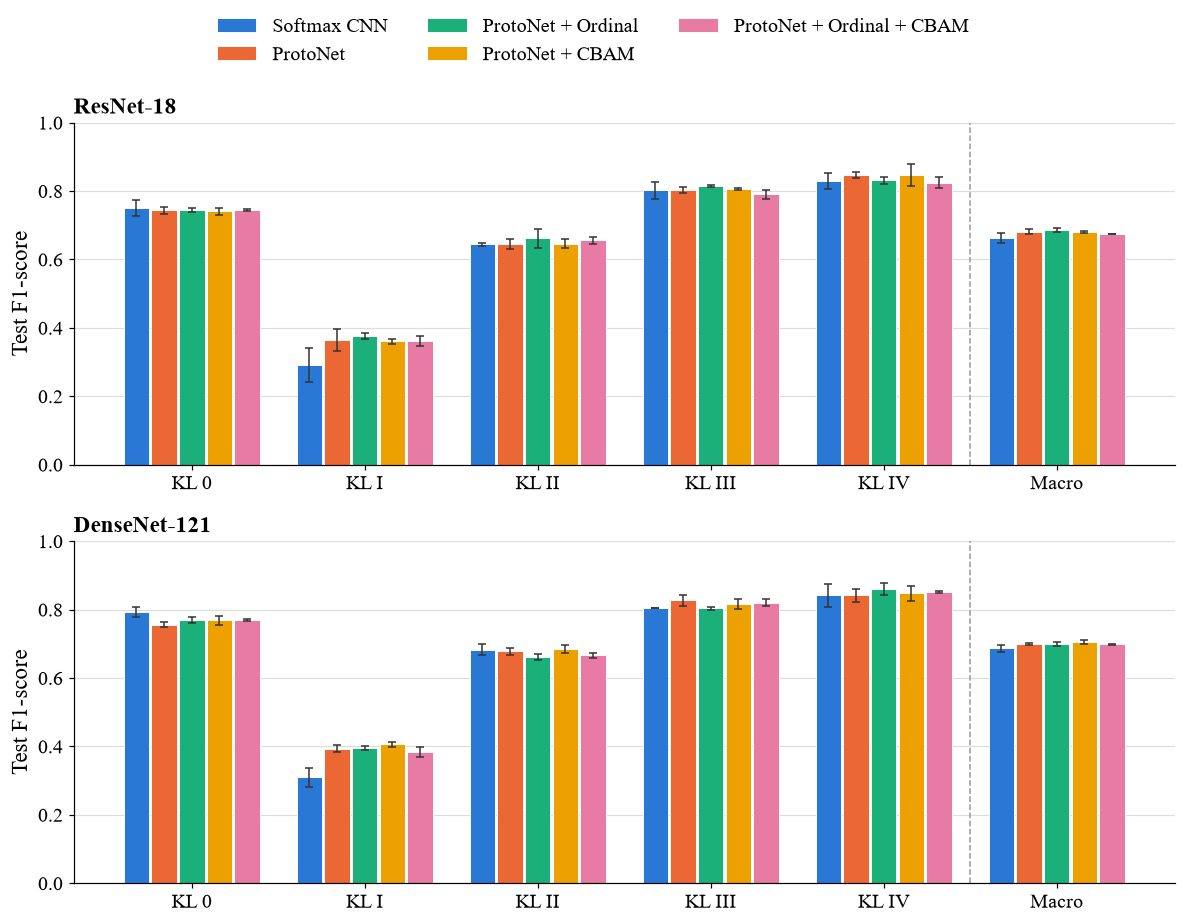

In [5]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'stix',
    'font.size': 14,
    'axes.titlesize': 15,
    'axes.labelsize': 15,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 13,
    'figure.dpi': 110,
    'savefig.dpi': 400,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.axisbelow': True,
    'axes.grid': True,
    'axes.grid.axis': 'y',
    'grid.color': '#dddddd',
    'grid.linewidth': 0.8,
})

# Colour-blind-safe categorical palette, one fixed colour per model
MODEL_COLORS = dict(zip(MODELS, ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4']))


def save_fig(fig, name):
    for ext in ('png', 'pdf'):
        fig.savefig(os.path.join(FIG_DIR, f'{name}.{ext}'))


groups = ['f1_kl0', 'f1_kl1', 'f1_kl2', 'f1_kl3', 'f1_kl4', 'f1_macro']
group_labels = ['KL 0', 'KL I', 'KL II', 'KL III', 'KL IV', 'Macro']
x = np.arange(len(groups))
width = 0.16

fig, axes = plt.subplots(2, 1, figsize=(11, 8.5), sharey=True)
for ax, backbone in zip(axes, BACKBONES):
    for i, model in enumerate(MODELS):
        means = [agg.loc[(backbone, model), (g, 'mean')] for g in groups]
        sds = [agg.loc[(backbone, model), (g, 'std')] for g in groups]
        ax.bar(x + (i - 2) * width, means, width * 0.92, yerr=sds, capsize=2.5,
               color=MODEL_COLORS[model], edgecolor='white', linewidth=0.6,
               error_kw=dict(elinewidth=1.0, ecolor='#333333'), label=MODEL_LABELS[model])
    ax.axvline(4.5, color='#999999', linestyle='--', linewidth=1.0)
    ax.set_xticks(x, group_labels)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Test F1-score')
    ax.set_title(BACKBONE_LABELS[backbone], loc='left', fontweight='bold')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.0))
fig.tight_layout(rect=[0, 0, 1, 0.92])
save_fig(fig, 'fig_per_grade_f1')
plt.show()

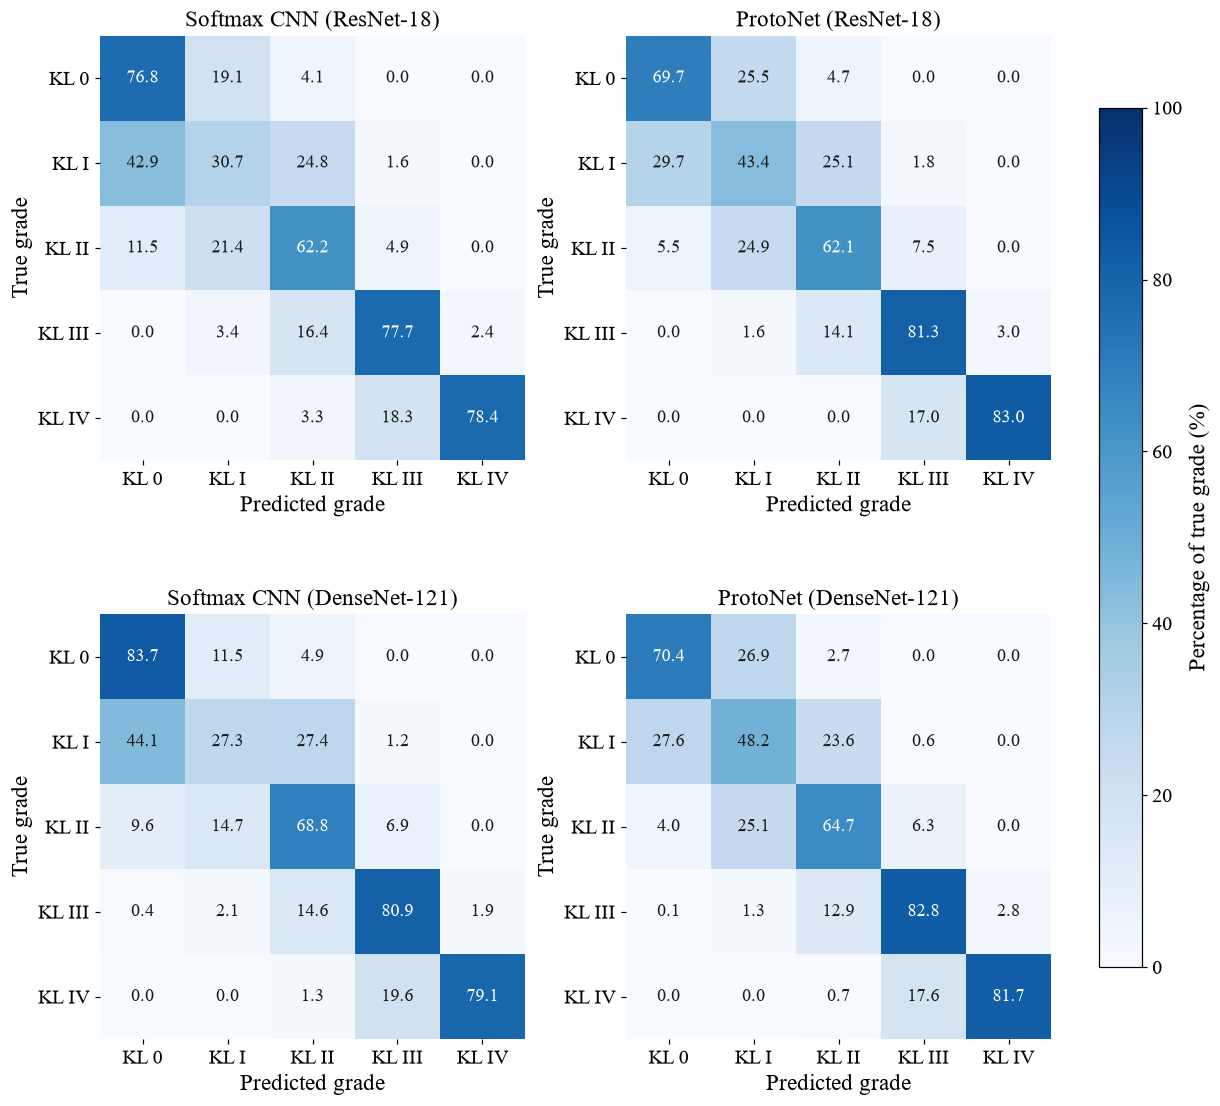

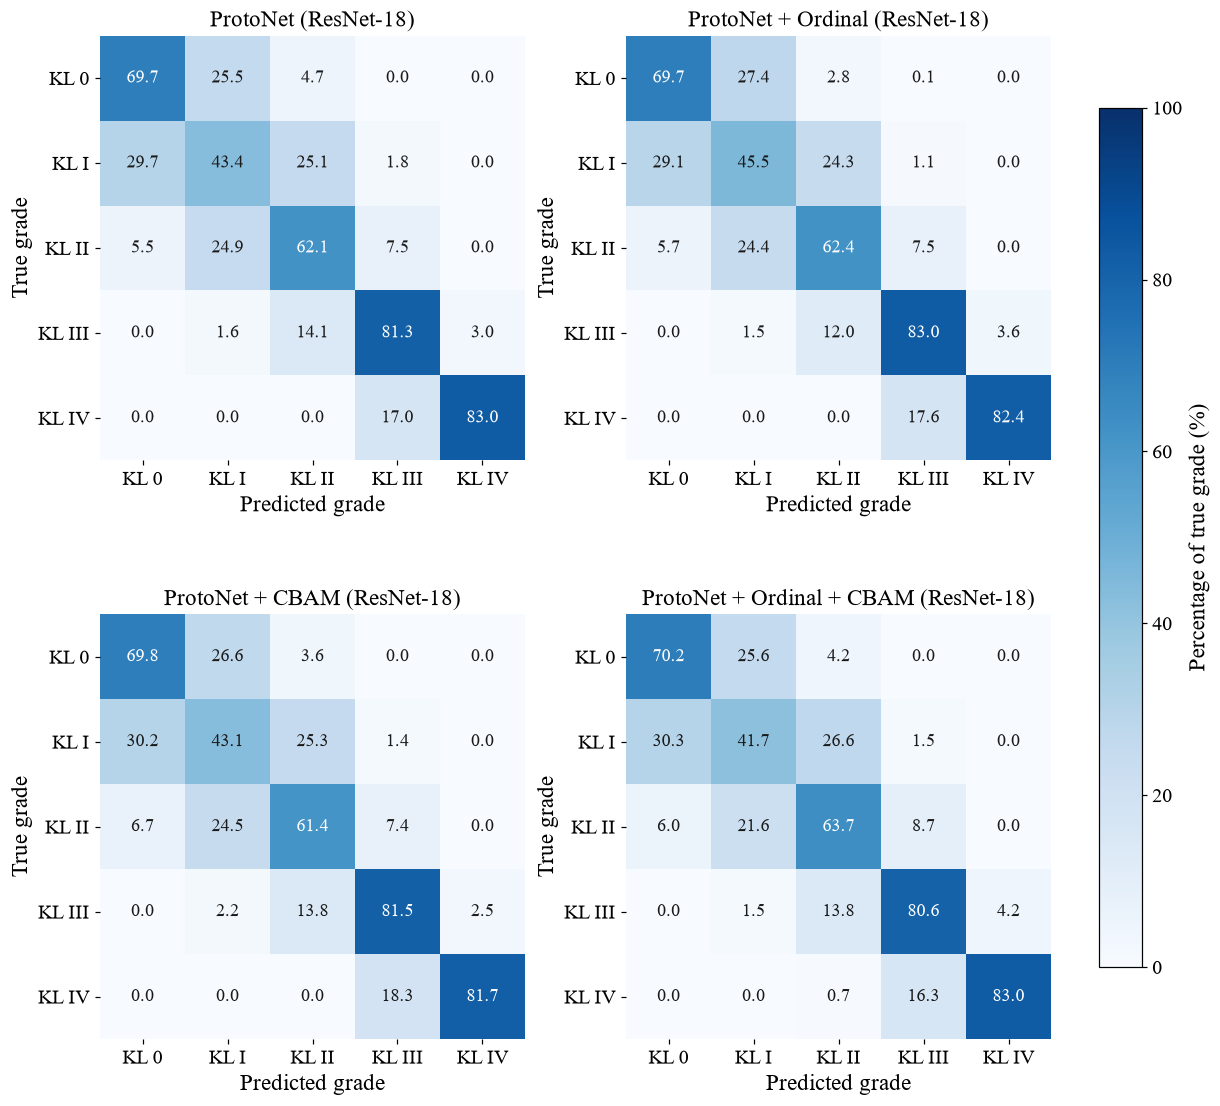

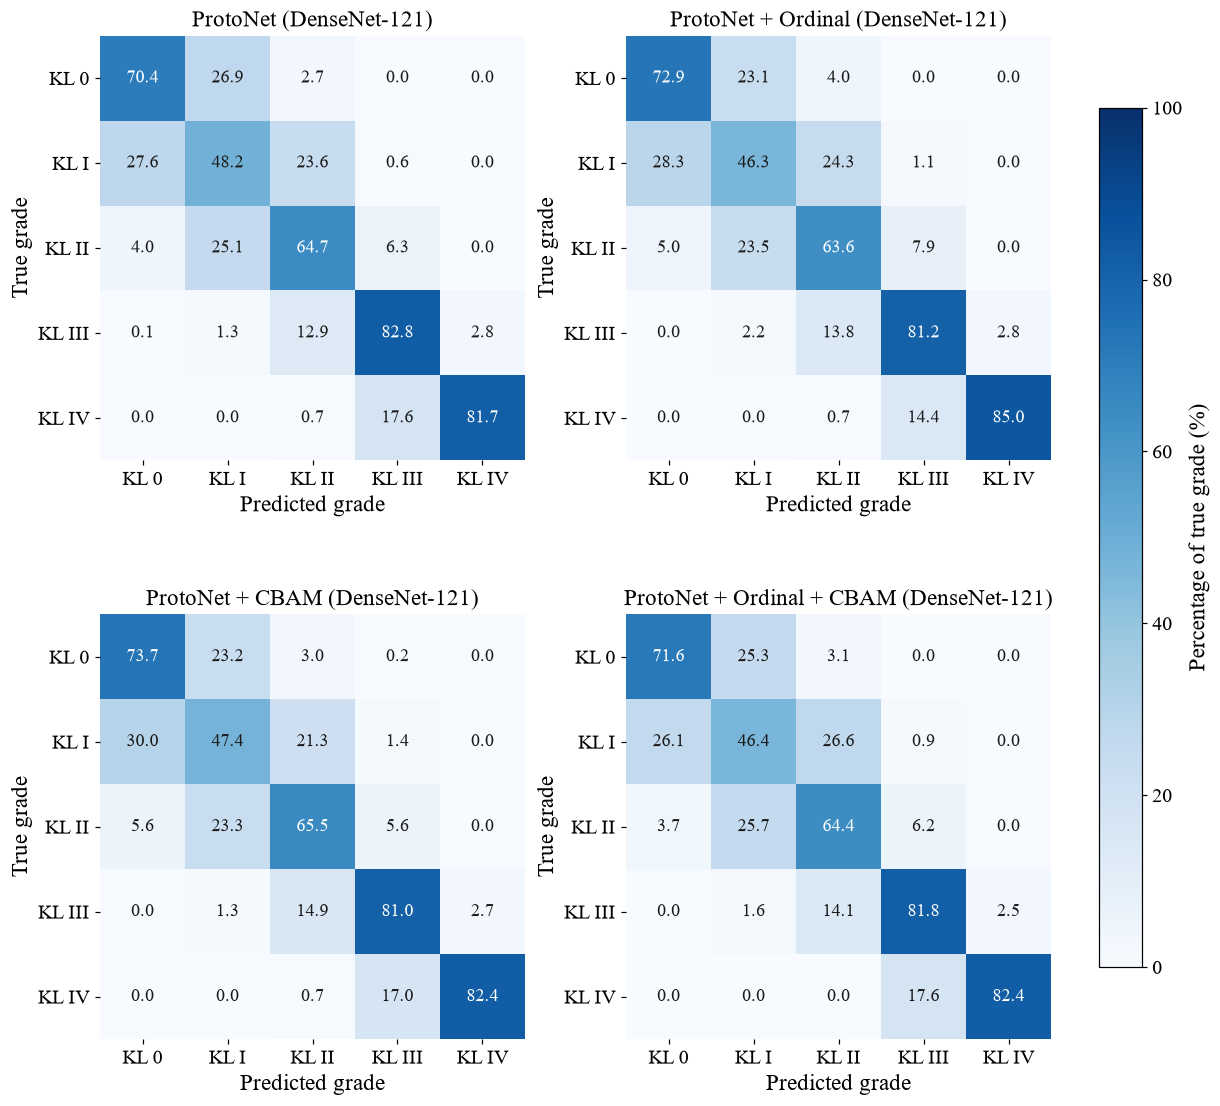

Per-grade recall and KL I errors (% of true grade, pooled over 3 seeds)
    Backbone                     Model  Recall KL 0  Recall KL I  Recall KL II  Recall KL III  Recall KL IV  KL I -> KL 0  KL I -> KL II
   ResNet-18               Softmax CNN         76.8         30.7          62.2           77.7          78.4          42.9           24.8
   ResNet-18                  ProtoNet         69.7         43.4          62.1           81.3          83.0          29.7           25.1
   ResNet-18        ProtoNet + Ordinal         69.7         45.5          62.4           83.0          82.4          29.1           24.3
   ResNet-18           ProtoNet + CBAM         69.8         43.1          61.4           81.5          81.7          30.2           25.3
   ResNet-18 ProtoNet + Ordinal + CBAM         70.2         41.7          63.7           80.6          83.0          30.3           26.6
DenseNet-121               Softmax CNN         83.7         27.3          68.8           80.9          79.

In [8]:
GRADE_LABELS = ['KL 0', 'KL I', 'KL II', 'KL III', 'KL IV']


def pooled_confusion(model, backbone):
    return sum(confusion(y_test, preds[f"{model}_{backbone}_seed{s}"]) for s in SEEDS)


def plot_confusion(ax, cm, title, annot_size=12):
    pct = 100 * cm / cm.sum(axis=1, keepdims=True)
    im = ax.imshow(pct, cmap='Blues', vmin=0, vmax=100)
    for i in range(K):
        for j in range(K):
            ax.text(j, i, f"{pct[i, j]:.1f}", ha='center', va='center', fontsize=annot_size,
                    color='white' if pct[i, j] > 55 else '#1a1a1a')
    ax.set_xticks(range(K), GRADE_LABELS)
    ax.set_yticks(range(K), GRADE_LABELS)
    ax.set_xlabel('Predicted grade')
    ax.set_ylabel('True grade')
    ax.set_title(title)
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    return im


# Main figure: softmax CNN vs ProtoNet
fig, axes = plt.subplots(2, 2, figsize=(11, 10.5), constrained_layout=True)
for r, backbone in enumerate(BACKBONES):
    for c, model in enumerate(['vanilla', 'baseline']):
        im = plot_confusion(axes[r, c], pooled_confusion(model, backbone),
                            f"{MODEL_LABELS[model]} ({BACKBONE_LABELS[backbone]})")
fig.colorbar(im, ax=axes, shrink=0.75, label='Percentage of true grade (%)')
save_fig(fig, 'fig_confusion_softmax_vs_protonet')
plt.show()

# Supplementary figures: the four prototypical variants, one figure per backbone
PROTO_MODELS = ['baseline', 'ordinal', 'attention', 'full']
for backbone in BACKBONES:
    fig, axes = plt.subplots(2, 2, figsize=(11, 10.5), constrained_layout=True)
    for ax, model in zip(axes.flat, PROTO_MODELS):
        im = plot_confusion(ax, pooled_confusion(model, backbone),
                            f"{MODEL_LABELS[model]} ({BACKBONE_LABELS[backbone]})")
    fig.colorbar(im, ax=axes, shrink=0.75, label='Percentage of true grade (%)')
    save_fig(fig, f'fig_confusion_protonet_variants_{backbone}')
    plt.show()

# Per-grade recall and the main KL I error, pooled over the three seeds
recall_rows = []
for backbone in BACKBONES:
    for model in MODELS:
        cm = pooled_confusion(model, backbone)
        row_pct = 100 * cm / cm.sum(axis=1, keepdims=True)
        recall_rows.append(dict(Backbone=BACKBONE_LABELS[backbone], Model=MODEL_LABELS[model],
                                **{f"Recall {g}": row_pct[k, k] for k, g in enumerate(GRADE_LABELS)},
                                **{"KL I -> KL 0": row_pct[1, 0], "KL I -> KL II": row_pct[1, 2]}))
recall_table = pd.DataFrame(recall_rows)
recall_table.to_csv(os.path.join(TAB_DIR, 'per_grade_recall.csv'), index=False)
print("Per-grade recall and KL I errors (% of true grade, pooled over 3 seeds)")
print(recall_table.round(1).to_string(index=False))

In [9]:
TRAIN_COUNTS = np.array([2286, 1046, 1516, 757, 173])
log_prior = np.log(TRAIN_COUNTS / TRAIN_COUNTS.sum())
TAUS = np.round(np.arange(0.0, 2.01, 0.1), 2)
METHOD_ORDER = ['Softmax CNN', 'Softmax CNN + LA (tau = 1)',
                'Softmax CNN + LA (tau tuned on val)', 'ProtoNet']

la_rows, method_preds = [], {}
for backbone in BACKBONES:
    for s in SEEDS:
        out = np.load(os.path.join(RUNS_DIR, f"vanilla_{backbone}_seed{s}", 'outputs.npz'))
        val_f1 = [metrics_from_cm(confusion(out['val_labels'],
                                            (out['val_logits'] - t * log_prior).argmax(1)))[1]
                  for t in TAUS]
        tau_val = float(TAUS[int(np.argmax(val_f1))])
        for method, tau in zip(METHOD_ORDER[:3], [0.0, 1.0, tau_val]):
            p = (out['test_logits'] - tau * log_prior).argmax(1)
            method_preds[(backbone, method, s)] = p
            la_rows.append(dict(backbone=backbone, method=method, seed=s, tau=tau,
                                **dict(zip(STAT_METRICS, metrics_from_cm(confusion(y_test, p))))))
        p = preds[f"baseline_{backbone}_seed{s}"]
        method_preds[(backbone, 'ProtoNet', s)] = p
        la_rows.append(dict(backbone=backbone, method='ProtoNet', seed=s, tau=np.nan,
                            **dict(zip(STAT_METRICS, metrics_from_cm(confusion(y_test, p))))))

la_df = pd.DataFrame(la_rows)
la_df.to_csv(os.path.join(TAB_DIR, 'logit_adjustment_all_runs.csv'), index=False)

la_agg = la_df.groupby(['backbone', 'method'], sort=False)[STAT_METRICS + ['tau']].agg(['mean', 'std'])
print("Test performance (mean ± SD, 3 seeds)")
for backbone in BACKBONES:
    print(f"\n{BACKBONE_LABELS[backbone]}")
    for method in METHOD_ORDER:
        r = la_agg.loc[(backbone, method)]
        cells = "  ".join(f"{m} {r[(m, 'mean')]:.3f} ± {r[(m, 'std')]:.3f}" for m in STAT_METRICS)
        tau_txt = '' if np.isnan(r[('tau', 'mean')]) else f"  (tau {la_df[(la_df.backbone == backbone) & (la_df.method == method)]['tau'].tolist()})"
        print(f"  {method:38s} {cells}{tau_txt}")

# Paired bootstrap: ProtoNet minus each logit-adjusted softmax variant
rng = np.random.default_rng(1)
comparisons = [('ProtoNet', 'Softmax CNN + LA (tau = 1)'),
               ('ProtoNet', 'Softmax CNN + LA (tau tuned on val)')]
boot_rows = []
for backbone in BACKBONES:
    for a, b in comparisons:
        obs = (np.mean([metrics_from_cm(confusion(y_test, method_preds[(backbone, a, s)])) for s in SEEDS], axis=0) -
               np.mean([metrics_from_cm(confusion(y_test, method_preds[(backbone, b, s)])) for s in SEEDS], axis=0))
        dist = np.empty((N_BOOT, len(STAT_METRICS)))
        for i in range(N_BOOT):
            idx = rng.integers(0, n_test, n_test)
            yb = y_test[idx]
            ma = np.mean([metrics_from_cm(confusion(yb, method_preds[(backbone, a, s)][idx])) for s in SEEDS], axis=0)
            mb = np.mean([metrics_from_cm(confusion(yb, method_preds[(backbone, b, s)][idx])) for s in SEEDS], axis=0)
            dist[i] = ma - mb
        lo, hi = np.percentile(dist, [2.5, 97.5], axis=0)
        p = np.minimum(1.0, 2 * np.minimum((dist <= 0).mean(axis=0), (dist >= 0).mean(axis=0)))
        for k, metric in enumerate(STAT_METRICS):
            boot_rows.append(dict(backbone=BACKBONE_LABELS[backbone], comparison=f"{a} vs {b}",
                                  metric=metric, diff=obs[k], ci_low=lo[k], ci_high=hi[k], p=p[k]))

la_stats = pd.DataFrame(boot_rows)
la_stats.to_csv(os.path.join(TAB_DIR, 'logit_adjustment_comparisons.csv'), index=False)
print("\nProtoNet minus logit-adjusted softmax: difference, 95% bootstrap CI, p")
for _, r in la_stats.iterrows():
    print(f"  {r['backbone']:12s} {r['comparison']:52s} {r['metric']:9s} "
          f"{r['diff']:+.3f} [{r['ci_low']:+.3f}, {r['ci_high']:+.3f}]  p={fmt_p(r['p'])}")

Test performance (mean ± SD, 3 seeds)

ResNet-18
  Softmax CNN                            accuracy 0.648 ± 0.008  f1_macro 0.664 ± 0.015  f1_kl1 0.292 ± 0.050  qwk 0.814 ± 0.007  (tau [0.0, 0.0, 0.0])
  Softmax CNN + LA (tau = 1)             accuracy 0.619 ± 0.029  f1_macro 0.652 ± 0.013  f1_kl1 0.332 ± 0.036  qwk 0.811 ± 0.004  (tau [1.0, 1.0, 1.0])
  Softmax CNN + LA (tau tuned on val)    accuracy 0.639 ± 0.019  f1_macro 0.661 ± 0.012  f1_kl1 0.299 ± 0.050  qwk 0.814 ± 0.006  (tau [0.1, 0.0, 0.5])
  ProtoNet                               accuracy 0.649 ± 0.005  f1_macro 0.681 ± 0.007  f1_kl1 0.365 ± 0.031  qwk 0.830 ± 0.008

DenseNet-121
  Softmax CNN                            accuracy 0.690 ± 0.012  f1_macro 0.687 ± 0.012  f1_kl1 0.309 ± 0.028  qwk 0.838 ± 0.007  (tau [0.0, 0.0, 0.0])
  Softmax CNN + LA (tau = 1)             accuracy 0.663 ± 0.006  f1_macro 0.689 ± 0.003  f1_kl1 0.375 ± 0.023  qwk 0.836 ± 0.003  (tau [1.0, 1.0, 1.0])
  Softmax CNN + LA (tau tuned on val)    accurac


f1_macro with K labelled support images per grade (mean over 100 episodes, then mean ± SD over 3 seeds)
  ResNet-18
    Softmax CNN                  K=1: 0.592 ± 0.015  K=5: 0.651 ± 0.009  K=10: 0.657 ± 0.009  K=20: 0.660 ± 0.009  K=all: 0.663 ± 0.013
    ProtoNet                     K=1: 0.607 ± 0.012  K=5: 0.666 ± 0.009  K=10: 0.675 ± 0.007  K=20: 0.677 ± 0.007  K=all: 0.681 ± 0.007
    ProtoNet + Ordinal           K=1: 0.612 ± 0.011  K=5: 0.670 ± 0.008  K=10: 0.679 ± 0.007  K=20: 0.683 ± 0.008  K=all: 0.686 ± 0.006
    ProtoNet + CBAM              K=1: 0.629 ± 0.004  K=5: 0.671 ± 0.001  K=10: 0.677 ± 0.004  K=20: 0.678 ± 0.004  K=all: 0.680 ± 0.003
    ProtoNet + Ordinal + CBAM    K=1: 0.611 ± 0.014  K=5: 0.666 ± 0.006  K=10: 0.674 ± 0.002  K=20: 0.675 ± 0.003  K=all: 0.675 ± 0.000
  DenseNet-121
    Softmax CNN                  K=1: 0.599 ± 0.013  K=5: 0.682 ± 0.003  K=10: 0.693 ± 0.008  K=20: 0.700 ± 0.010  K=all: 0.705 ± 0.012
    ProtoNet                     K=1: 0.630 ± 0.016 

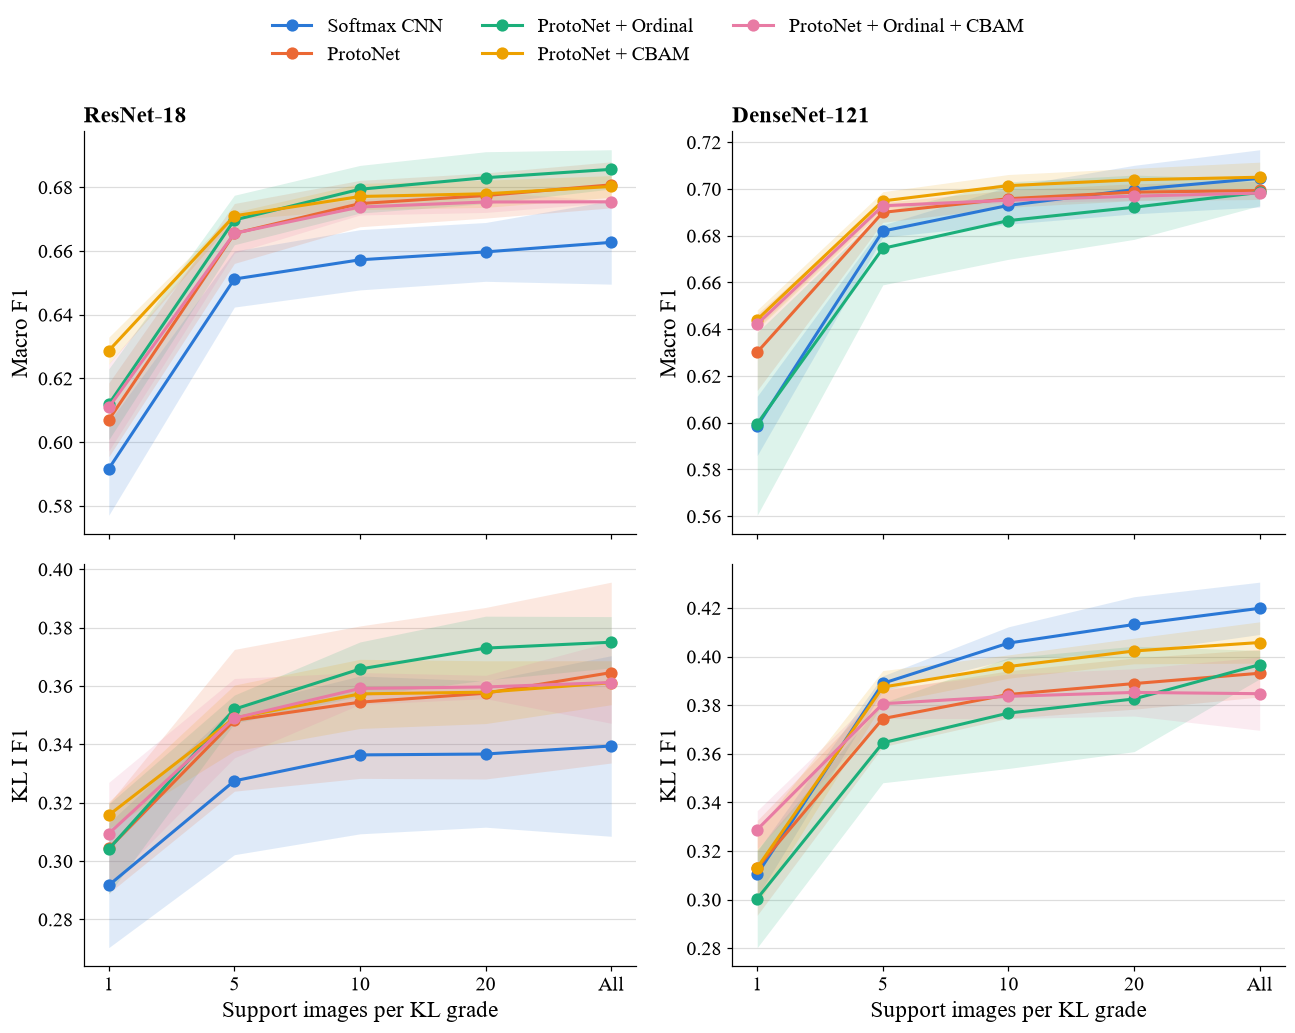

In [10]:
K_SHOTS = [1, 5, 10, 20, 'all']
N_EPISODES = 100


def nearest_prototype(test_emb, test_sq, prototypes):
    # argmin of squared Euclidean distance; the |test|^2 term does not change the argmin
    return (-2 * test_emb @ prototypes.T + (prototypes ** 2).sum(axis=1)).argmin(axis=1)


rng = np.random.default_rng(2)
kshot_rows = []
for run in expected:
    out = np.load(os.path.join(RUNS_DIR, run, 'outputs.npz'))
    train_emb = out['train_emb'].astype(np.float32)
    train_lbl = out['train_labels']
    test_emb = out['test_emb'].astype(np.float32)
    test_sq = (test_emb ** 2).sum(axis=1)
    class_idx = [np.where(train_lbl == k)[0] for k in range(K)]
    model, backbone, seed_tag = run.split('_')

    for shot in K_SHOTS:
        if shot == 'all':
            supports = [class_idx]
        else:
            supports = [[rng.choice(ci, shot, replace=False) for ci in class_idx] for _ in range(N_EPISODES)]
        episode_metrics = np.array([
            metrics_from_cm(confusion(y_test, nearest_prototype(
                test_emb, test_sq, np.stack([train_emb[idx].mean(axis=0) for idx in sup]))))
            for sup in supports
        ])
        kshot_rows.append(dict(model=model, backbone=backbone,
                               seed=int(seed_tag.replace('seed', '')), shot=str(shot),
                               **{m: episode_metrics[:, i].mean() for i, m in enumerate(STAT_METRICS)}))

kshot = pd.DataFrame(kshot_rows)
kshot.to_csv(os.path.join(TAB_DIR, 'kshot_all_runs.csv'), index=False)

SHOT_LABELS = [str(s) for s in K_SHOTS]
kshot_agg = kshot.groupby(['backbone', 'model', 'shot'])[STAT_METRICS].agg(['mean', 'std'])

for metric in ['f1_macro', 'f1_kl1']:
    print(f"\n{metric} with K labelled support images per grade "
          f"(mean over {N_EPISODES} episodes, then mean ± SD over 3 seeds)")
    for backbone in BACKBONES:
        print(f"  {BACKBONE_LABELS[backbone]}")
        for model in MODELS:
            cells = "  ".join(
                f"K={s}: {kshot_agg.loc[(backbone, model, s), (metric, 'mean')]:.3f} "
                f"± {kshot_agg.loc[(backbone, model, s), (metric, 'std')]:.3f}" for s in SHOT_LABELS)
            print(f"    {MODEL_LABELS[model]:28s} {cells}")

# Figure: macro F1 and KL I F1 against the number of support images
fig, axes = plt.subplots(2, 2, figsize=(12, 9.5), sharex=True)
xpos = np.arange(len(SHOT_LABELS))
for c, backbone in enumerate(BACKBONES):
    for r, (metric, ylabel) in enumerate([('f1_macro', 'Macro F1'), ('f1_kl1', 'KL I F1')]):
        ax = axes[r, c]
        for model in MODELS:
            mu = np.array([kshot_agg.loc[(backbone, model, s), (metric, 'mean')] for s in SHOT_LABELS])
            sd = np.array([kshot_agg.loc[(backbone, model, s), (metric, 'std')] for s in SHOT_LABELS])
            ax.plot(xpos, mu, marker='o', markersize=7, linewidth=2,
                    color=MODEL_COLORS[model], label=MODEL_LABELS[model])
            ax.fill_between(xpos, mu - sd, mu + sd, color=MODEL_COLORS[model], alpha=0.15, linewidth=0)
        ax.set_xticks(xpos, ['1', '5', '10', '20', 'All'])
        ax.set_ylabel(ylabel)
        if r == 0:
            ax.set_title(BACKBONE_LABELS[backbone], loc='left', fontweight='bold')
        if r == 1:
            ax.set_xlabel('Support images per KL grade')
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.0))
fig.tight_layout(rect=[0, 0, 1, 0.92])
save_fig(fig, 'fig_kshot')
plt.show()

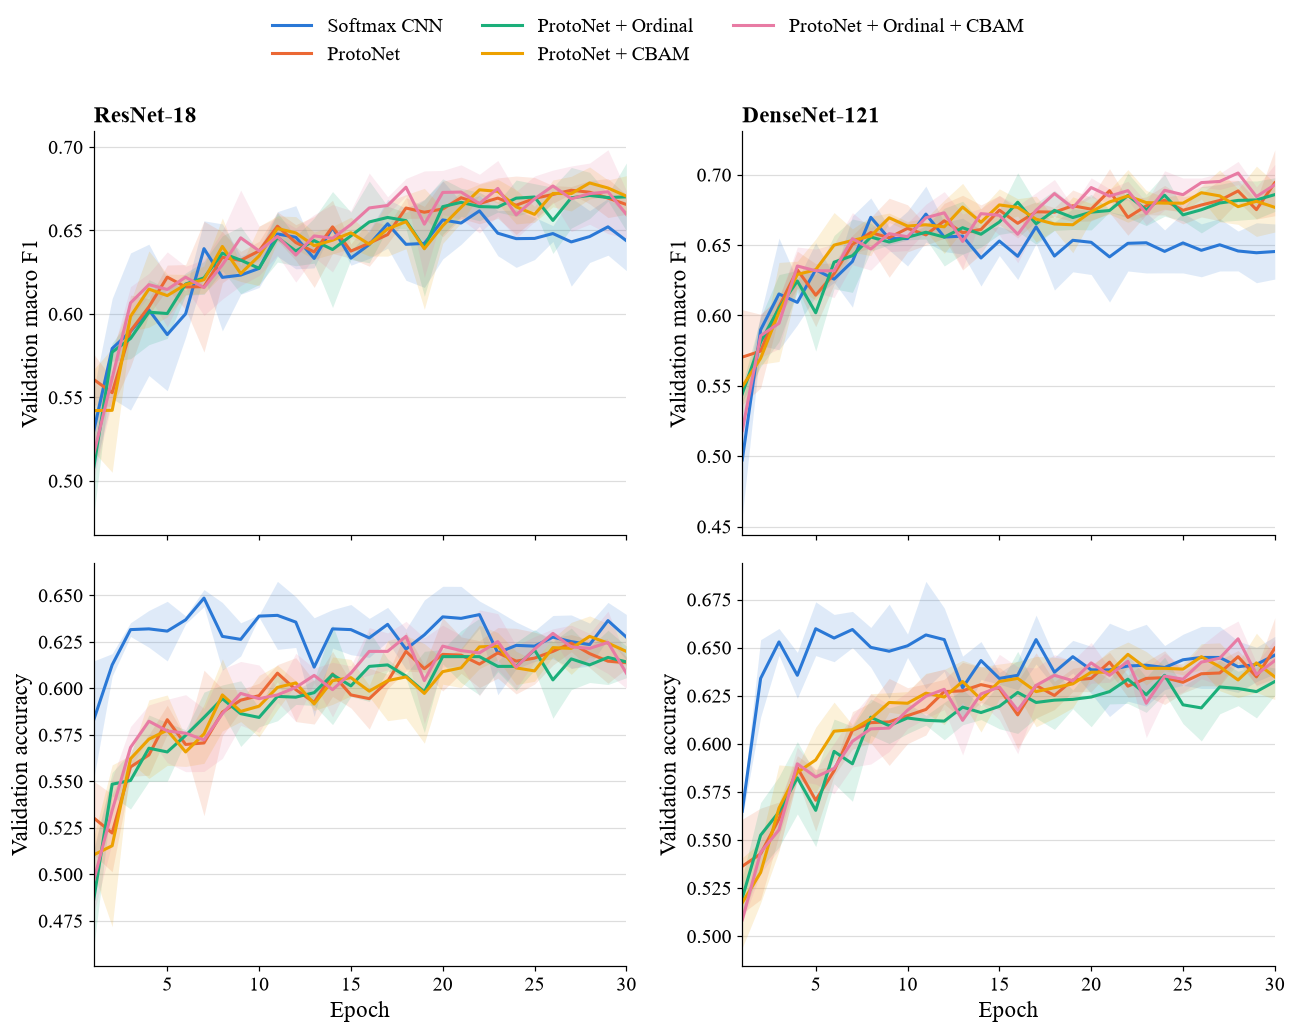

Epoch with the best validation macro F1 (selected checkpoint)
                                          mean  min  max
ResNet-18 / Softmax CNN                   16.3   12   20
ResNet-18 / ProtoNet                      24.7   21   29
ResNet-18 / ProtoNet + Ordinal            26.3   24   30
ResNet-18 / ProtoNet + CBAM               28.7   28   30
ResNet-18 / ProtoNet + Ordinal + CBAM     23.0   18   29
DenseNet-121 / Softmax CNN                10.3    8   12
DenseNet-121 / ProtoNet                   24.7   21   30
DenseNet-121 / ProtoNet + Ordinal         21.7   13   30
DenseNet-121 / ProtoNet + CBAM            24.0   21   29
DenseNet-121 / ProtoNet + Ordinal + CBAM  26.7   24   28


In [11]:
histories = []
for run in expected:
    with open(os.path.join(RUNS_DIR, run, 'history.json')) as f:
        h = pd.DataFrame(json.load(f))
    model, backbone, seed_tag = run.split('_')
    h['model'], h['backbone'], h['seed'] = model, backbone, int(seed_tag.replace('seed', ''))
    histories.append(h[['model', 'backbone', 'seed', 'epoch', 'val_f1_macro', 'val_accuracy']])
hist = pd.concat(histories, ignore_index=True)
hist_agg = hist.groupby(['backbone', 'model', 'epoch'])[['val_f1_macro', 'val_accuracy']].agg(['mean', 'std'])

fig, axes = plt.subplots(2, 2, figsize=(12, 9.5), sharex=True)
for c, backbone in enumerate(BACKBONES):
    for r, (metric, ylabel) in enumerate([('val_f1_macro', 'Validation macro F1'),
                                          ('val_accuracy', 'Validation accuracy')]):
        ax = axes[r, c]
        for model in MODELS:
            sub = hist_agg.loc[(backbone, model)]
            epochs = sub.index.to_numpy()
            mu, sd = sub[(metric, 'mean')].to_numpy(), sub[(metric, 'std')].to_numpy()
            ax.plot(epochs, mu, linewidth=2, color=MODEL_COLORS[model], label=MODEL_LABELS[model])
            ax.fill_between(epochs, mu - sd, mu + sd, color=MODEL_COLORS[model], alpha=0.15, linewidth=0)
        ax.set_ylabel(ylabel)
        ax.set_xlim(1, CFG_EPOCHS := int(hist['epoch'].max()))
        if r == 0:
            ax.set_title(BACKBONE_LABELS[backbone], loc='left', fontweight='bold')
        if r == 1:
            ax.set_xlabel('Epoch')
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.0))
fig.tight_layout(rect=[0, 0, 1, 0.92])
save_fig(fig, 'fig_training_curves')
plt.show()

best_epochs = df.groupby(['backbone', 'model'], observed=True)['best_epoch'].agg(['mean', 'min', 'max'])
best_epochs.index = [f"{BACKBONE_LABELS[b]} / {MODEL_LABELS[m]}" for b, m in best_epochs.index]
print("Epoch with the best validation macro F1 (selected checkpoint)")
print(best_epochs.round(1).to_string())

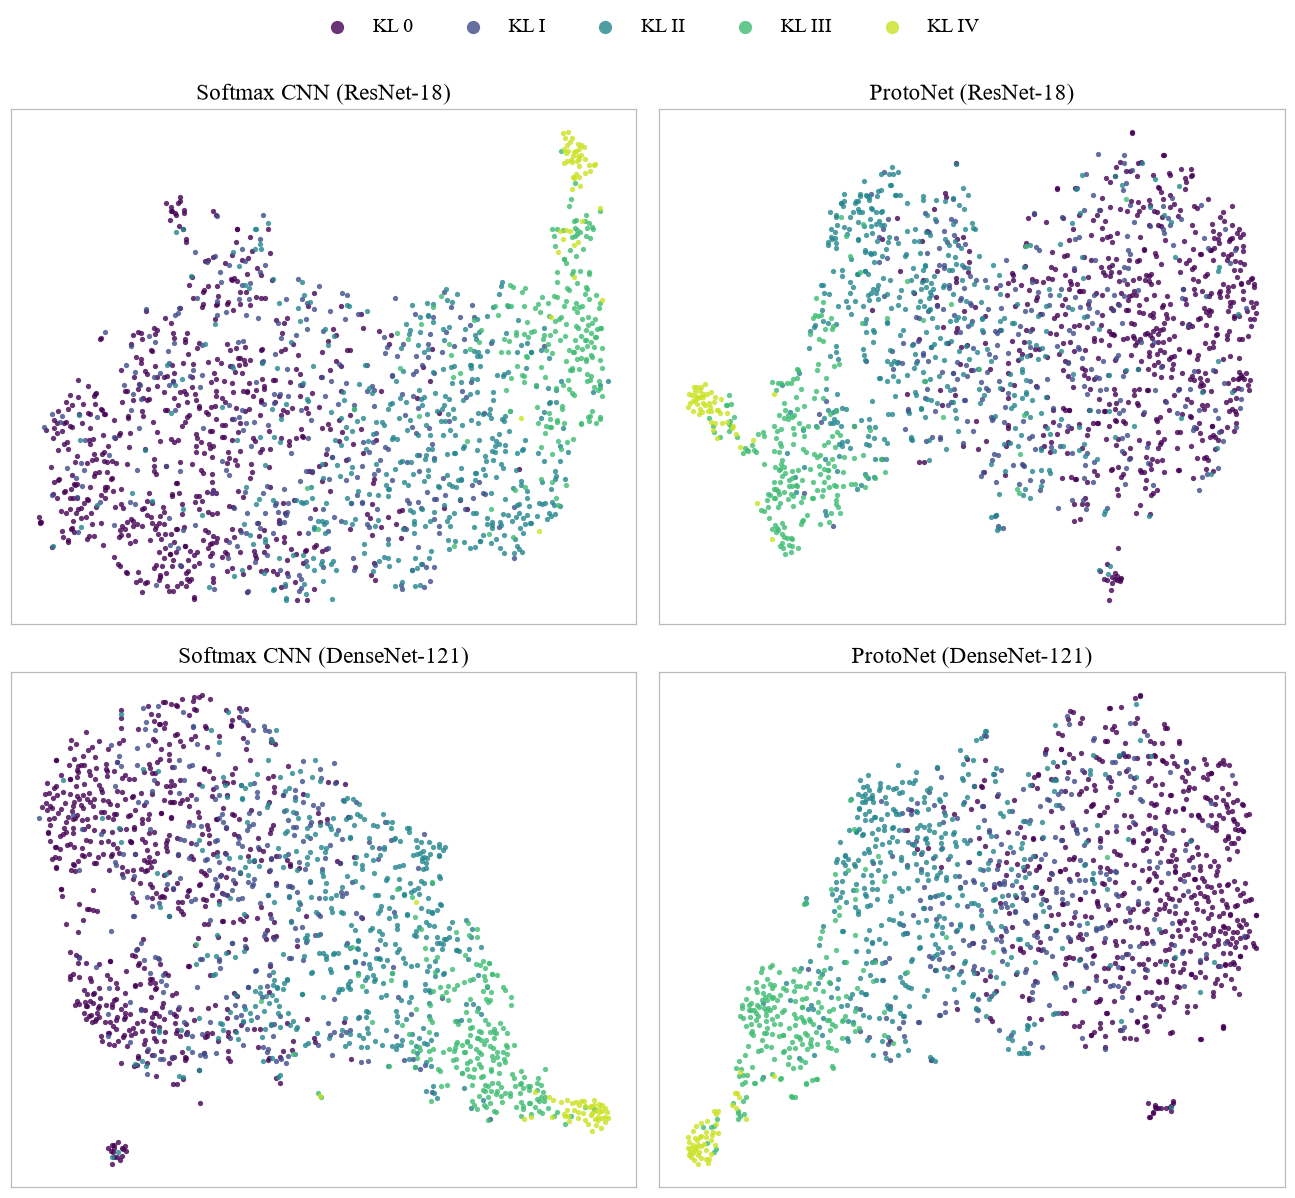

Ordinal arrangement of class prototypes (mean ± SD, 3 seeds)
spearman_rho: rank correlation between grade gap |i - j| and prototype distance (1 = perfectly ordered)
constraint: number of k (out of 3) with d(k, k+2) > d(k, k+1)

  ResNet-18    Softmax CNN                  rho 0.833 ± 0.000   constraint 3.00 ± 0.00 / 3
  ResNet-18    ProtoNet                     rho 0.712 ± 0.000   constraint 3.00 ± 0.00 / 3
  ResNet-18    ProtoNet + Ordinal           rho 0.712 ± 0.000   constraint 3.00 ± 0.00 / 3
  ResNet-18    ProtoNet + CBAM              rho 0.712 ± 0.000   constraint 3.00 ± 0.00 / 3
  ResNet-18    ProtoNet + Ordinal + CBAM    rho 0.712 ± 0.000   constraint 3.00 ± 0.00 / 3
  DenseNet-121 Softmax CNN                  rho 0.792 ± 0.070   constraint 3.00 ± 0.00 / 3
  DenseNet-121 ProtoNet                     rho 0.737 ± 0.044   constraint 3.00 ± 0.00 / 3
  DenseNet-121 ProtoNet + Ordinal           rho 0.737 ± 0.044   constraint 3.00 ± 0.00 / 3
  DenseNet-121 ProtoNet + CBAM              

In [12]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from scipy.stats import spearmanr

GRADE_COLORS = plt.cm.viridis(np.linspace(0.0, 0.92, K))

fig, axes = plt.subplots(2, 2, figsize=(12, 11))
for r, backbone in enumerate(BACKBONES):
    for c, model in enumerate(['vanilla', 'baseline']):
        emb = np.load(os.path.join(RUNS_DIR, f"{model}_{backbone}_seed0", 'outputs.npz'))['test_emb']
        z = PCA(n_components=50, random_state=0).fit_transform(emb.astype(np.float32))
        xy = TSNE(n_components=2, perplexity=30, init='pca', random_state=0).fit_transform(z)
        ax = axes[r, c]
        for k in range(K):
            mask = y_test == k
            ax.scatter(xy[mask, 0], xy[mask, 1], s=12, color=GRADE_COLORS[k], alpha=0.8,
                       linewidths=0, label=GRADE_LABELS[k])
        ax.set_title(f"{MODEL_LABELS[model]} ({BACKBONE_LABELS[backbone]})")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(False)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color('#bbbbbb')
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=5, frameon=False,
           bbox_to_anchor=(0.5, 1.0), markerscale=2.5)
fig.tight_layout(rect=[0, 0, 1, 0.95])
save_fig(fig, 'fig_tsne')
plt.show()

# Ordinal arrangement of the class prototypes, computed in the full embedding space
pairs = [(i, j) for i in range(K) for j in range(i + 1, K)]
grade_gap = [j - i for i, j in pairs]
order_rows = []
for run in expected:
    out = np.load(os.path.join(RUNS_DIR, run, 'outputs.npz'))
    emb, lbl = out['train_emb'].astype(np.float32), out['train_labels']
    protos = np.stack([emb[lbl == k].mean(axis=0) for k in range(K)])
    dist = lambda i, j: np.linalg.norm(protos[i] - protos[j])
    model, backbone, seed_tag = run.split('_')
    order_rows.append(dict(
        model=model, backbone=backbone, seed=int(seed_tag.replace('seed', '')),
        spearman_rho=spearmanr(grade_gap, [dist(i, j) for i, j in pairs]).correlation,
        constraint_satisfied=sum(dist(k, k + 2) > dist(k, k + 1) for k in range(K - 2)),
    ))

order_df = pd.DataFrame(order_rows)
order_df.to_csv(os.path.join(TAB_DIR, 'prototype_ordering_all_runs.csv'), index=False)
order_agg = order_df.groupby(['backbone', 'model'], sort=False)[['spearman_rho', 'constraint_satisfied']].agg(['mean', 'std'])

print("Ordinal arrangement of class prototypes (mean ± SD, 3 seeds)")
print("spearman_rho: rank correlation between grade gap |i - j| and prototype distance (1 = perfectly ordered)")
print("constraint: number of k (out of 3) with d(k, k+2) > d(k, k+1)\n")
for backbone in BACKBONES:
    for model in MODELS:
        r = order_agg.loc[(backbone, model)]
        print(f"  {BACKBONE_LABELS[backbone]:12s} {MODEL_LABELS[model]:28s} "
              f"rho {r[('spearman_rho', 'mean')]:.3f} ± {r[('spearman_rho', 'std')]:.3f}   "
              f"constraint {r[('constraint_satisfied', 'mean')]:.2f} ± {r[('constraint_satisfied', 'std')]:.2f} / 3")

In [13]:
check_rows = []
for run in [r for r in expected if r.split('_')[0] in ('ordinal', 'full')]:
    with open(os.path.join(RUNS_DIR, run, 'history.json')) as f:
        h = pd.DataFrame(json.load(f))
    protos = np.load(os.path.join(RUNS_DIR, run, 'outputs.npz'))['prototypes']
    adjacent = np.mean([np.linalg.norm(protos[k] - protos[k + 1]) for k in range(K - 1)])
    check_rows.append(dict(run=run,
                           ord_epoch1=h['train_ord'].iloc[0],
                           ord_epoch5=h['train_ord'].iloc[4],
                           ord_epoch30=h['train_ord'].iloc[-1],
                           ce_epoch1=h['train_ce'].iloc[0],
                           ce_epoch30=h['train_ce'].iloc[-1],
                           adjacent_proto_dist=adjacent))

ord_check = pd.DataFrame(check_rows)
ord_check.to_csv(os.path.join(TAB_DIR, 'ordinal_loss_activity.csv'), index=False)
print("Mean ordinal hinge term per training epoch vs classification loss (margin = 0.5)")
print(ord_check.round(4).to_string(index=False))

Mean ordinal hinge term per training epoch vs classification loss (margin = 0.5)
                      run  ord_epoch1  ord_epoch5  ord_epoch30  ce_epoch1  ce_epoch30  adjacent_proto_dist
   ordinal_resnet18_seed0      0.2066      0.0340       0.0000     1.2994      0.4391               7.1057
   ordinal_resnet18_seed1      0.1719      0.0442       0.0052     1.2966      0.4929               5.7837
   ordinal_resnet18_seed2      0.1883      0.0501       0.0005     1.2888      0.4672               6.8596
ordinal_densenet121_seed0      0.2277      0.0212       0.0044     1.3144      0.3864               6.6510
ordinal_densenet121_seed1      0.2171      0.0327       0.0027     1.3210      0.4219               7.6344
ordinal_densenet121_seed2      0.2150      0.0309       0.0023     1.2821      0.4172               8.8536
      full_resnet18_seed0      0.1903      0.0190       0.0033     1.2489      0.4139               6.3882
      full_resnet18_seed1      0.1172      0.0273       0.0024 

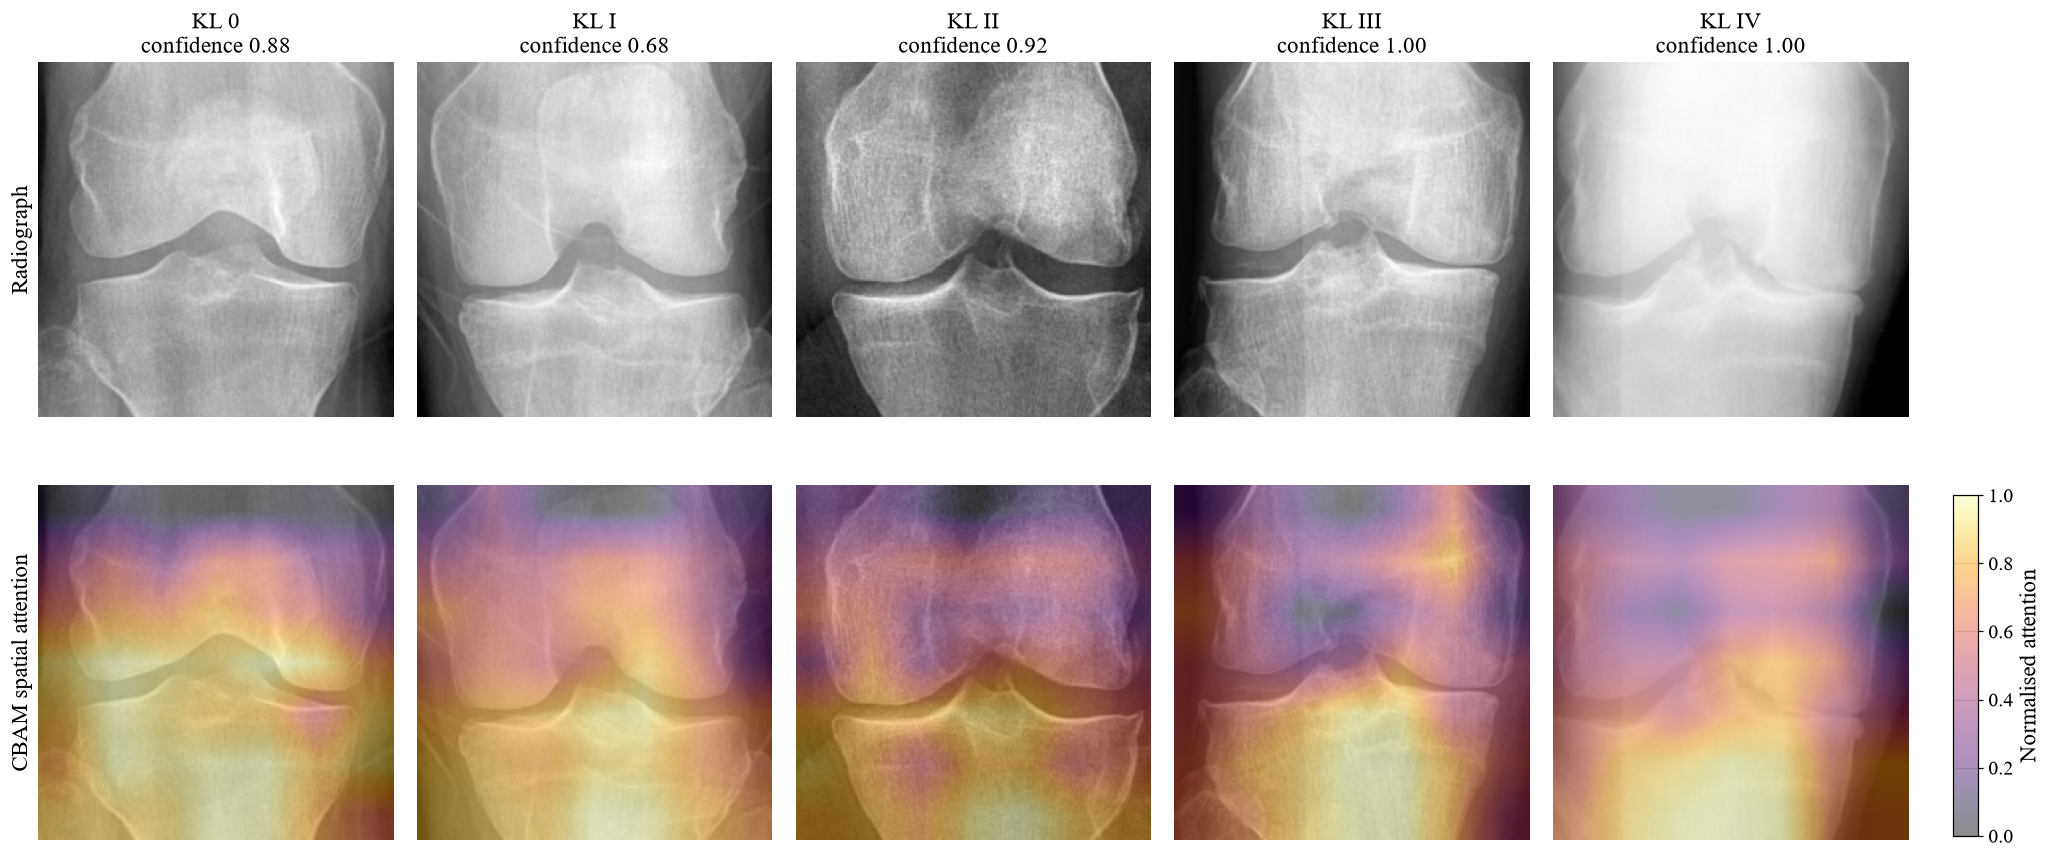

Images shown:
  KL 0: test/0/9088396R.png  (confidence 0.881)
  KL I: test/1/9021428L.png  (confidence 0.681)
  KL II: test/2/9768219L.png  (confidence 0.924)
  KL III: test/3/9201046R.png  (confidence 0.997)
  KL IV: test/4/9012867R.png  (confidence 1.000)


In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torchvision import models
from PIL import Image

LOCAL_DATA = r'E:\KNEE_fewshot\data\data'   # contains train/ val/ test/
ATTN_RUN = 'attention_densenet121_seed0'


class CBAM(nn.Module):
    """Same definition as in 01_train.ipynb."""

    def __init__(self, channels, reduction=16, kernel_size=7):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1, bias=False),
        )
        self.spatial = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.last_spatial_map = None

    def forward(self, x):
        channel_att = torch.sigmoid(self.mlp(F.adaptive_avg_pool2d(x, 1)) +
                                    self.mlp(F.adaptive_max_pool2d(x, 1)))
        x = x * channel_att
        pooled = torch.cat([x.mean(dim=1, keepdim=True), x.amax(dim=1, keepdim=True)], dim=1)
        spatial_att = torch.sigmoid(self.spatial(pooled))
        self.last_spatial_map = spatial_att.detach()
        return x * spatial_att


class EmbeddingNet(nn.Module):
    """Same architecture as in 01_train.ipynb; weights are loaded from the checkpoint."""

    def __init__(self, backbone, use_attention, reduction=16):
        super().__init__()
        if backbone == 'resnet18':
            base = models.resnet18(weights=None)
            self.features = nn.Sequential(*list(base.children())[:-2])
            self.out_dim = 512
        else:
            base = models.densenet121(weights=None)
            self.features = nn.Sequential(base.features, nn.ReLU(inplace=True))
            self.out_dim = 1024
        self.attention = CBAM(self.out_dim, reduction) if use_attention else None

    def forward(self, x):
        fmap = self.features(x)
        if self.attention is not None:
            fmap = self.attention(fmap)
        return F.adaptive_avg_pool2d(fmap, 1).flatten(1)


net = EmbeddingNet('densenet121', use_attention=True)
net.load_state_dict(torch.load(os.path.join(RUNS_DIR, ATTN_RUN, 'best_model.pth'), map_location='cpu'))
net.eval()

eval_tf = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# One correctly classified test image per grade: the one closest to the median confidence
out = np.load(os.path.join(RUNS_DIR, ATTN_RUN, 'outputs.npz'))
attn_probs, attn_preds, test_files = out['test_probs'], out['test_preds'], out['test_files']
chosen = []
for k in range(K):
    idx = np.where((y_test == k) & (attn_preds == k))[0]
    conf = attn_probs[idx, k]
    chosen.append(idx[np.argmin(np.abs(conf - np.median(conf)))])

fig, axes = plt.subplots(2, K, figsize=(19, 8.6))
for c, i in enumerate(chosen):
    path = os.path.join(LOCAL_DATA, str(test_files[i]))
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    img = Image.open(path).convert('RGB')
    with torch.no_grad():
        net(eval_tf(img).unsqueeze(0))
    att = F.interpolate(net.attention.last_spatial_map, size=(224, 224),
                        mode='bilinear', align_corners=False)[0, 0].numpy()
    att = (att - att.min()) / (att.max() - att.min() + 1e-8)
    gray = np.asarray(img.convert('L').resize((224, 224)))

    axes[0, c].imshow(gray, cmap='gray')
    axes[0, c].set_title(f"{GRADE_LABELS[c]}\nconfidence {attn_probs[i, c]:.2f}")
    axes[1, c].imshow(gray, cmap='gray')
    im = axes[1, c].imshow(att, cmap='inferno', alpha=0.45, vmin=0, vmax=1)
    for ax in axes[:, c]:
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(False)
        for spine in ax.spines.values():
            spine.set_visible(False)
axes[0, 0].set_ylabel('Radiograph')
axes[1, 0].set_ylabel('CBAM spatial attention')
fig.tight_layout(rect=[0, 0, 0.93, 1])
cax = fig.add_axes([0.94, 0.08, 0.012, 0.36])
fig.colorbar(im, cax=cax, label='Normalised attention')
save_fig(fig, 'fig_attention_maps')
plt.show()

print("Images shown:")
for k, i in enumerate(chosen):
    print(f"  {GRADE_LABELS[k]}: {test_files[i]}  (confidence {attn_probs[i, k]:.3f})")

In [15]:
import re
import hashlib

SPLITS = ['train', 'val', 'test']
IMG_EXT = ('.png', '.jpg', '.jpeg')

counts, patients, hashes = {}, {}, {}
for split in SPLITS:
    counts[split] = []
    patients[split] = set()
    for k in range(K):
        class_dir = os.path.join(LOCAL_DATA, split, str(k))
        files = sorted(f for f in os.listdir(class_dir) if f.lower().endswith(IMG_EXT))
        counts[split].append(len(files))
        for fname in files:
            patients[split].add(re.match(r'(\d{7})', fname).group(1))  # OAI patient ID
            with open(os.path.join(class_dir, fname), 'rb') as fh:
                hashes.setdefault(hashlib.md5(fh.read()).hexdigest(), set()).add(split)

# Table 1: images per KL grade and split
total = np.sum([counts[s] for s in SPLITS], axis=0)
table1 = pd.DataFrame({
    'KL grade': ['0', 'I', 'II', 'III', 'IV'],
    'Description': ['Healthy', 'Doubtful', 'Minimal', 'Moderate', 'Severe'],
    'Train': counts['train'],
    'Validation': counts['val'],
    'Test': counts['test'],
    'Total': total,
    'Percentage': np.round(100 * total / total.sum(), 2),
})
table1.loc[len(table1)] = ['Total', '', sum(counts['train']), sum(counts['val']),
                           sum(counts['test']), int(total.sum()), 100.0]
table1.to_csv(os.path.join(TAB_DIR, 'table_dataset_distribution.csv'), index=False)
print("Dataset distribution")
print(table1.to_string(index=False))

# Patient-level split and duplicate checks
print("\nUnique patients: " + ", ".join(f"{s} {len(patients[s])}" for s in SPLITS))
for a, b in [('train', 'val'), ('train', 'test'), ('val', 'test')]:
    print(f"Patients shared by {a} and {b}: {len(patients[a] & patients[b])}")
n_images = int(total.sum())
cross_split = sum(len(s) > 1 for s in hashes.values())
print(f"Identical image files (MD5) across splits: {cross_split} (of {n_images} images, "
      f"{len(hashes)} unique hashes)")

Dataset distribution
KL grade Description  Train  Validation  Test  Total  Percentage
       0     Healthy   2286         328   639   3253       39.38
       I    Doubtful   1046         153   296   1495       18.10
      II     Minimal   1516         212   447   2175       26.33
     III    Moderate    757         106   223   1086       13.15
      IV      Severe    173          27    51    251        3.04
   Total               5778         826  1656   8260      100.00

Unique patients: train 2889, val 413, test 828
Patients shared by train and val: 0
Patients shared by train and test: 0
Patients shared by val and test: 0
Identical image files (MD5) across splits: 0 (of 8260 images, 8260 unique hashes)
